# 03. AutoIntent: Few-Shot Experiments

Анализ результатов AutoIntent на CLINC150 в few-shot режиме (10/20/50-shot).

**Запуск из терминала (рекомендуется):**
```bash
cd tasks/oos_detection
uv run python scripts/train_autointent.py --mode fewshot --n_shots 10 --seed 42 --pilot
uv run python scripts/eval_autointent.py --model_dir runs/autointent_classic-light_pilot_10shot_seed42
```

**Или можно запустить обучение прямо в ноутбуке** (секция 3).

## Содержание
1. Setup
2. Что такое classic-light
3. Обучение (опционально)
4. Загрузка результатов
5. Сравнение с бейзлайнами (10-shot)
6. Выводы (10-shot)
7. Variance Analysis (10-shot)
8. Scaling Curve (10/20/50-shot)
9. Анализ AutoML выбора

## 1. Setup

In [ ]:
# Load environment variables from .env (macOS ARM fix)
from dotenv import load_dotenv
load_dotenv("../../../.env")  # project root

import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
PROCESSED = TASK_DIR / "data" / "processed"
RESULTS = TASK_DIR / "results"
RUNS = TASK_DIR / "runs"

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(TASK_DIR))

# Data source
SOURCE = "deeppavlov"  # or "standard"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS}")
print(f"Runs dir: {RUNS}")

import os
print(f"\nOMP_NUM_THREADS={os.environ.get('OMP_NUM_THREADS', 'not set')}")

## 2. Что такое classic-light

AutoIntent использует preset-конфигурации для AutoML поиска.

**classic-light** включает:
- **Scoring модули:** knn (k=1..20), linear, mlknn
- **Decision модули:** threshold, argmax, jinoos, tunable, adaptive
- **HPO:** TPE sampler, 20 trials
- **Embedder:** multilingual-e5-large-instruct (или e5-small для pilot)

In [22]:
# Show available trained models
print("Trained models in runs/:")
print("=" * 50)

if RUNS.exists():
    for model_dir in sorted(RUNS.iterdir()):
        if model_dir.is_dir():
            metadata_file = model_dir / "train_metadata.json"
            if metadata_file.exists():
                meta = json.loads(metadata_file.read_text())
                status = "ready"
            else:
                status = "incomplete"
            print(f"  {model_dir.name} [{status}]")
else:
    print("  (no models trained yet)")

Trained models in runs/:
  autointent_classic-light_10shot_seed123 [ready]
  autointent_classic-light_10shot_seed42 [ready]
  autointent_classic-light_10shot_seed456 [ready]
  autointent_classic-light_20shot_seed123 [ready]
  autointent_classic-light_20shot_seed42 [ready]
  autointent_classic-light_20shot_seed456 [ready]
  autointent_classic-light_50shot_seed123 [ready]
  autointent_classic-light_50shot_seed42 [ready]
  autointent_classic-light_50shot_seed456 [ready]
  autointent_classic-light_full_seed42 [ready]
  autointent_classic-light_pilot_10shot_seed42 [ready]


## 3. Обучение (опционально)

Можно запустить обучение прямо здесь. Если модель уже обучена — пропустите эту секцию.

In [23]:
# Settings
N_SHOTS = 10
SEED = 42
PILOT = True  # Use small embedder for faster training

MODE_STR = f"{N_SHOTS}shot"
MODEL_NAME = "autointent_classic-light_pilot" if PILOT else "autointent_classic-light"
MODEL_DIR = RUNS / f"{MODEL_NAME}_{MODE_STR}_seed{SEED}"

# Check if already trained
if (MODEL_DIR / "train_metadata.json").exists():
    print(f"Model already exists: {MODEL_DIR}")
    print("Skip to section 4, or delete the directory to retrain.")
    NEED_TRAINING = False
else:
    print(f"Model not found. Will train to: {MODEL_DIR}")
    NEED_TRAINING = True

Model already exists: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/runs/autointent_classic-light_pilot_10shot_seed42
Skip to section 4, or delete the directory to retrain.


In [ ]:
# Run this cell ONLY if NEED_TRAINING = True
if NEED_TRAINING:
    from autointent import Pipeline, Dataset as AIDataset
    from autointent.configs import LoggingConfig, EmbedderConfig, DataConfig
    from src.data_utils import (
        load_split_autointent,
        load_fewshot_autointent,
        get_intents,
    )

    # Load data
    train_ai = load_fewshot_autointent(SOURCE, N_SHOTS, SEED)
    test_ai = load_split_autointent(SOURCE, "test")
    intents = get_intents(SOURCE)

    print(f"Train: {len(train_ai)} samples")
    print(f"Test: {len(test_ai)} samples")
    print(f"Intents: {len(intents)}")

    # Create dataset
    ai_dataset = AIDataset.from_dict({
        "train": train_ai,
        "test": test_ai,
        "intents": intents,
    })

    # Create pipeline
    pipeline = Pipeline.from_preset("classic-light")
    
    embedder_name = "intfloat/multilingual-e5-small" if PILOT else "intfloat/multilingual-e5-large-instruct"
    pipeline.set_config(EmbedderConfig(model_name=embedder_name))
    pipeline.set_config(DataConfig(scheme="cv", n_folds=3))
    
    RUNS.mkdir(parents=True, exist_ok=True)
    pipeline.set_config(LoggingConfig(
        project_dir=MODEL_DIR,
        dump_modules=True,
        clear_ram=False,
    ))

    print(f"\nStarting training with embedder: {embedder_name}")
    print("This may take a few minutes...")
else:
    print("Skipping training - model already exists.")

In [25]:
%%time
# Train (run only if NEED_TRAINING)
if NEED_TRAINING:
    context = pipeline.fit(ai_dataset)
    print("\nAutoML optimization completed!")
    
    # Save
    pipeline.dump(MODEL_DIR)
    
    metadata = {
        "model_name": MODEL_NAME,
        "mode": MODE_STR,
        "n_shots": N_SHOTS,
        "seed": SEED,
        "embedder": embedder_name,
        "pilot": PILOT,
        "preset": "classic-light",
    }
    (MODEL_DIR / "train_metadata.json").write_text(json.dumps(metadata, indent=2))
    print(f"Model saved to: {MODEL_DIR}")
else:
    print("Skipping - model already exists.")

Skipping - model already exists.
CPU times: user 37 μs, sys: 7 μs, total: 44 μs
Wall time: 44.8 μs


In [ ]:
# Evaluate trained model and save metrics
if NEED_TRAINING or (MODEL_DIR / "train_metadata.json").exists():
    from autointent import Pipeline
    from src.data_utils import load_split
    from src.metrics import compute_all_metrics, measure_latency, get_oos_scores_from_pipeline
    from src.evaluation import Evaluator, EvaluationResult
    
    # Load model (if not already in memory)
    if 'pipeline' not in dir() or pipeline is None:
        print("Loading model from disk...")
        pipeline = Pipeline.load(MODEL_DIR)
    
    # Load test data
    test_std = load_split(SOURCE, "test")
    test_texts = test_std["texts"]
    test_labels = np.array(test_std["labels"])
    
    print(f"Test samples: {len(test_texts)}")
    
    # Predictions
    print("Running predictions...")
    raw_preds = pipeline.predict(test_texts)
    y_pred = np.array([-1 if p is None else p for p in raw_preds])
    print(f"OOS predictions: {(y_pred == -1).sum()}")
    
    # Get continuous OOS scores for AUROC
    y_scores = get_oos_scores_from_pipeline(pipeline, test_texts)
    n_unique = len(np.unique(y_scores))
    print(f"OOS scores: {n_unique} unique values ({'continuous' if n_unique > 2 else 'binary fallback'})")
    
    # Compute metrics
    metrics = compute_all_metrics(
        y_true=test_labels,
        y_scores=y_scores,
        y_pred=y_pred,
    )
    
    # Measure latency
    class PipelineWrapper:
        def __init__(self, pipe):
            self.pipe = pipe
        def predict(self, texts):
            preds = self.pipe.predict(texts)
            return np.array([-1 if p is None else p for p in preds])
    
    wrapper = PipelineWrapper(pipeline)
    latency = measure_latency(wrapper, test_texts[:100])
    
    # Save result
    result = EvaluationResult(
        model_name=MODEL_NAME,
        mode=MODE_STR,
        oos_recall=metrics["oos_recall"],
        in_domain_acc=metrics["in_domain_acc"],
        f1_oos=metrics["f1_oos"],
        auroc=metrics["auroc"],
        au_ioc=metrics["au_ioc"],
        latency_ms=latency,
        n_shots=N_SHOTS,
        seed=SEED,
        extra={
            "preset": "classic-light",
            "embedder": embedder_name if 'embedder_name' in dir() else "unknown",
            "pilot": PILOT,
        },
    )
    
    evaluator = Evaluator(test_std, RESULTS)
    evaluator.save(result)
    
    # Print results
    print(f"\n{'='*50}")
    print(f"AutoIntent Results ({MODE_STR})")
    print(f"{'='*50}")
    print(f"  OOS Recall:    {metrics['oos_recall']:.4f}")
    print(f"  In-Domain Acc: {metrics['in_domain_acc']:.4f}")
    print(f"  F1 OOS:        {metrics['f1_oos']:.4f}")
    print(f"  AUROC:         {metrics['auroc']:.4f}")
    print(f"  Latency:       {latency:.2f} ms")
    print(f"\nResults saved to {RESULTS / 'metrics.json'}")
else:
    print("No model to evaluate. Run training first.")

## 4. Загрузка результатов

In [27]:
# Load all results
metrics_file = RESULTS / "metrics.json"

if not metrics_file.exists():
    print("metrics.json not found!")
    print("Run baselines first: python scripts/run_baseline.py")
else:
    all_results = json.loads(metrics_file.read_text())
    df = pd.DataFrame(all_results)
    print(f"Loaded {len(df)} results")
    print(f"Models: {df['model_name'].unique().tolist()}")

Loaded 91 results
Models: ['tfidf_argmax', 'tfidf_threshold', 'cosine_bert_argmax', 'cosine_bert_threshold', 'cosine_minilm_argmax', 'cosine_minilm_threshold', 'cosine_e5large_argmax', 'cosine_e5large_threshold', 'autointent_classic-light', 'autointent_classic-light_pilot']


In [28]:
# Check if AutoIntent results exist
autointent_models = df[df['model_name'].str.contains('autointent', case=False)]

if len(autointent_models) == 0:
    print("AutoIntent results not found!")
    print("Run section 3 above, or use terminal:")
    print("  uv run python scripts/train_autointent.py --pilot")
    print("  uv run python scripts/eval_autointent.py --model_dir runs/...")
else:
    print(f"Found {len(autointent_models)} AutoIntent result(s):")
    for _, row in autointent_models.iterrows():
        print(f"  - {row['model_name']} ({row['mode']}): F1={row['f1_oos']:.4f}")

Found 11 AutoIntent result(s):
  - autointent_classic-light (10shot): F1=0.7488
  - autointent_classic-light (10shot): F1=0.7061
  - autointent_classic-light (20shot): F1=0.8193
  - autointent_classic-light (20shot): F1=0.8316
  - autointent_classic-light (20shot): F1=0.8075
  - autointent_classic-light (50shot): F1=0.7283
  - autointent_classic-light (50shot): F1=0.7235
  - autointent_classic-light (50shot): F1=0.7370
  - autointent_classic-light (full): F1=0.8413
  - autointent_classic-light_pilot (10shot): F1=0.6827
  - autointent_classic-light (10shot): F1=0.7182


## 5. Сравнение с бейзлайнами (10-shot)

In [29]:
# Filter 10-shot results and compute mean ± std by model
df_10shot = df[df["mode"] == "10shot"].copy()

# Group by model and compute statistics
def format_mean_std(series):
    """Format as mean ± std or just value if single sample."""
    if len(series) == 1:
        return f"{series.values[0]:.4f}"
    return f"{series.mean():.4f} ± {series.std():.4f}"

# Aggregate metrics
agg_metrics = df_10shot.groupby("model_name").agg({
    "oos_recall": ["mean", "std", "count"],
    "in_domain_acc": ["mean", "std"],
    "f1_oos": ["mean", "std"],
    "auroc": ["mean", "std"],
    "latency_ms": ["mean", "std"],
}).reset_index()

# Flatten column names
agg_metrics.columns = ["_".join(col).strip("_") for col in agg_metrics.columns]

# Sort by f1_oos_mean
agg_metrics = agg_metrics.sort_values("f1_oos_mean", ascending=False)

# Create display table with mean ± std format
display_df = pd.DataFrame({
    "Model": agg_metrics["model_name"],
    "OOS Recall": agg_metrics.apply(
        lambda r: f"{r['oos_recall_mean']:.4f} ± {r['oos_recall_std']:.4f}" 
        if r['oos_recall_count'] > 1 else f"{r['oos_recall_mean']:.4f}", axis=1),
    "In-Domain Acc": agg_metrics.apply(
        lambda r: f"{r['in_domain_acc_mean']:.4f} ± {r['in_domain_acc_std']:.4f}" 
        if r['oos_recall_count'] > 1 else f"{r['in_domain_acc_mean']:.4f}", axis=1),
    "F1 OOS": agg_metrics.apply(
        lambda r: f"{r['f1_oos_mean']:.4f} ± {r['f1_oos_std']:.4f}" 
        if r['oos_recall_count'] > 1 else f"{r['f1_oos_mean']:.4f}", axis=1),
    "AUROC": agg_metrics.apply(
        lambda r: f"{r['auroc_mean']:.4f} ± {r['auroc_std']:.4f}" 
        if r['oos_recall_count'] > 1 else f"{r['auroc_mean']:.4f}", axis=1),
    "Latency (ms)": agg_metrics["latency_ms_mean"].apply(lambda x: f"{x:.2f}"),
    "Seeds": agg_metrics["oos_recall_count"].astype(int),
})

print("10-shot Results (mean ± std across seeds)")
print("=" * 80)
display(display_df)

10-shot Results (mean ± std across seeds)


,Model,OOS Recall,In-Domain Acc,F1 OOS,AUROC,Latency (ms),Seeds
0,autointent_classic-light,0.6200 ± 0.0272,0.9201 ± 0.0024,0.7244 ± 0.0220,0.9593 ± 0.0012,0.22,3
1,autointent_classic-light_pilot,0.6230,0.8617,0.6827,0.9330,0.19,1
5,cosine_e5large_threshold,0.5297 ± 0.0766,0.8573 ± 0.0012,0.6601 ± 0.0572,0.9433 ± 0.0020,1.58,3
7,cosine_minilm_threshold,0.4963 ± 0.1006,0.8176 ± 0.0061,0.6245 ± 0.0774,0.9459 ± 0.0012,0.79,3
2,cosine_bert_argmax,0.9457 ± 0.0038,0.3615 ± 0.0033,0.4267 ± 0.0031,0.8273 ± 0.0003,15.94,3
4,cosine_e5large_argmax,0.2717 ± 0.0121,0.8639 ± 0.0037,0.4207 ± 0.0157,0.9433 ± 0.0020,34.47,3
3,cosine_bert_threshold,0.2713 ± 0.0545,0.6584 ± 0.0069,0.3659 ± 0.0439,0.8273 ± 0.0003,1.47,3
6,cosine_minilm_argmax,0.9993 ± 0.0006,0.1954 ± 0.0085,0.3565 ± 0.0019,0.9459 ± 0.0012,3.38,3
9,tfidf_threshold,0.1320 ± 0.0155,0.7343 ± 0.0064,0.2214 ± 0.0186,0.7687 ± 0.0058,2.50,3
8,tfidf_argmax,0.0003 ± 0.0006,0.7415 ± 0.0033,0.0007 ± 0.0012,0.7687 ± 0.0058,1.24,3


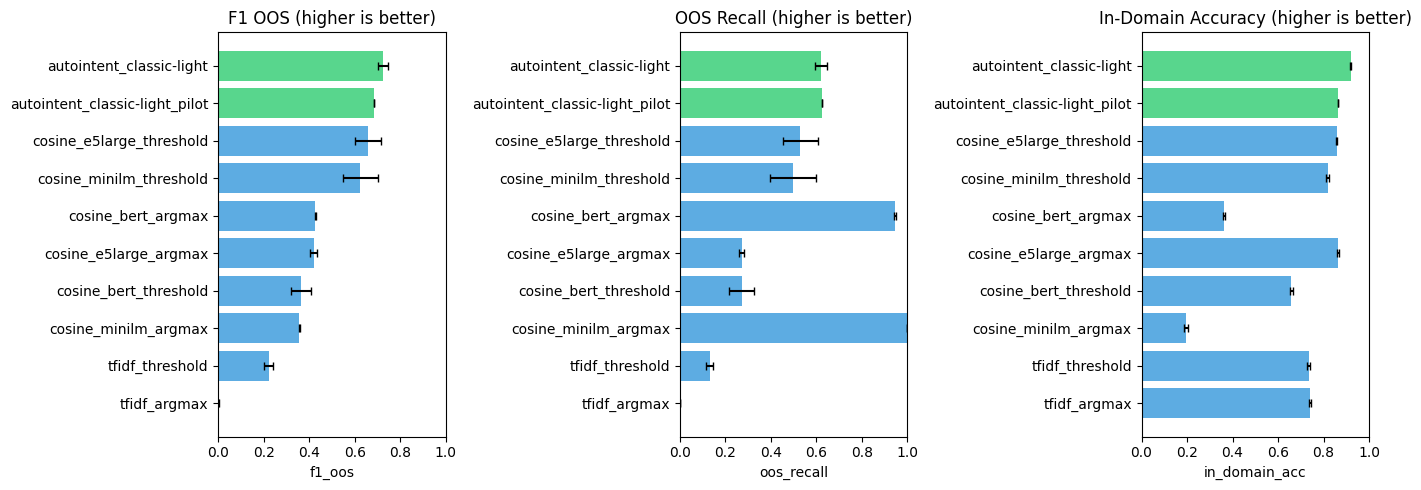

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/comparison_10shot.png


In [30]:
# Visual comparison with error bars for seeds variance
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics_to_plot = [
    ("f1_oos", "F1 OOS (higher is better)"),
    ("oos_recall", "OOS Recall (higher is better)"),
    ("in_domain_acc", "In-Domain Accuracy (higher is better)"),
]

# Use aggregated metrics for plotting
plot_data = agg_metrics.sort_values("f1_oos_mean", ascending=True)

for ax, (metric, title) in zip(axes, metrics_to_plot):
    y_pos = np.arange(len(plot_data))
    means = plot_data[f"{metric}_mean"].values
    stds = plot_data[f"{metric}_std"].fillna(0).values
    
    colors = ['#2ecc71' if 'autointent' in m.lower() else '#3498db' 
              for m in plot_data['model_name']]
    
    ax.barh(y_pos, means, xerr=stds, color=colors, capsize=3, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data['model_name'])
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS / "comparison_10shot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS / 'comparison_10shot.png'}")

## 6. Выводы (10-shot)

### Ключевые наблюдения

**1. AutoIntent лучше лучшего бейзлайна по всем
основным метрикам при 10-shot:**
- F1 OOS: 0.724 vs 0.660 (+6.4 п.п.)
- In-Domain Acc: 0.920 vs 0.857 (+6.3 п.п.)
- OOS Recall: 0.620 vs 0.530 (+9.0 п.п.)
- AUROC: 0.959 vs 0.946 (+1.3 п.п.)

**2. Embedder критичен: full vs pilot.**
Замена `e5-small` на `e5-large-instruct` дала +4 п.п. F1
и +5.8 п.п. In-Domain Acc. Большой multilingual embedder
существенно лучше справляется с intent classification.

**3. Latency компромисс.**
Full AutoIntent: ~0.2ms/запрос с предзагруженными embeddings.
Pilot (e5-small): аналогичный latency, но F1 ниже на ~4 п.п.
Выбор embedder'а — это трейдофф качество vs размер модели.

**4. AUROC сравним между всеми методами.**
AUROC для AutoIntent вычисляется по continuous OOS-скорам
(1 - max_class_prob) из scoring-модуля, что даёт корректное
сравнение с бейзлайнами.

### Ограничения

- Результаты усреднены по 3 seeds (42, 123, 456)
- PILOT режим несравним с Table 3 по embedder'у
- SOTA берём из литературы

### Выводы по вариативности бейзлайнов

**Данные** (mean ± std, 3 seeds, 10-shot):
- `cosine_minilm_threshold`:  F1 = 0.625 ± 0.077, CV ≈ 12%
- `cosine_e5large_threshold`: F1 = 0.660 ± 0.057, CV ≈ 9%
- `autointent_classic-light`: F1 = 0.724 ± 0.022, CV ≈ 3%

**Наблюдения:**

1. **AutoIntent в 3–4 раза стабильнее бейзлайнов** по дисперсии F1.

2. **Seed=42 был аномально удачным для MiniLM** (F1=0.697 на одном
   сиде vs 0.625 в среднем) — без усреднения разрыв с AutoIntent
   был бы занижен почти вдвое.

3. **In-Domain Acc стабилен у всех моделей** (std < 0.01),
   нестабильность сосредоточена именно в OOS-детекции.

# 7. Variance Analysis (10-shot)

Анализ стабильности результатов AutoIntent по трём seeds (42, 123, 456).

In [31]:
# 7.1 Load results for variance analysis
results_var = json.loads((RESULTS / "metrics.json").read_text())
df_var = pd.DataFrame(results_var)

# AutoIntent 10-shot across all seeds (full, not pilot)
ai_10shot = df_var[
    (df_var["model_name"] == "autointent_classic-light") &
    (df_var["n_shots"] == 10)
].sort_values("seed")

print(f"AutoIntent 10-shot records: {len(ai_10shot)}")
if len(ai_10shot) > 0:
    print(f"Seeds found: {ai_10shot['seed'].tolist()}")
else:
    print("No AutoIntent results found yet.")

AutoIntent 10-shot records: 3
Seeds found: [42.0, 123.0, 456.0]


In [32]:
# 7.2 Table by seeds
if len(ai_10shot) >= 1:
    # Display table with statistics
    display_cols = ["seed", "oos_recall", "in_domain_acc", "f1_oos", "latency_ms"]
    table_df = ai_10shot[display_cols].copy()
    table_df.columns = ["Seed", "OOS Recall", "In-Domain Acc", "F1 OOS", "Latency (ms)"]
    
    # Add mean and std rows
    numeric_cols = ["OOS Recall", "In-Domain Acc", "F1 OOS", "Latency (ms)"]
    mean_row = {"Seed": "mean"}
    std_row = {"Seed": "std"}
    for col in numeric_cols:
        mean_row[col] = table_df[col].mean()
        std_row[col] = table_df[col].std()
    
    table_df = pd.concat([table_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
    
    # Format
    for col in numeric_cols:
        table_df[col] = table_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
    
    print("AutoIntent 10-shot Results by Seed")
    print("=" * 60)
    display(table_df)
else:
    print("[Данные в процессе получения — запустите seed=123, 456]")

AutoIntent 10-shot Results by Seed


,Seed,OOS Recall,In-Domain Acc,F1 OOS,Latency (ms)
0,42.0,0.6130,0.9215,0.7182,0.2225
1,123.0,0.6500,0.9215,0.7488,0.2125
2,456.0,0.5970,0.9173,0.7061,0.2149
3,mean,0.6200,0.9201,0.7244,0.2166
4,std,0.0272,0.0024,0.0220,0.0052


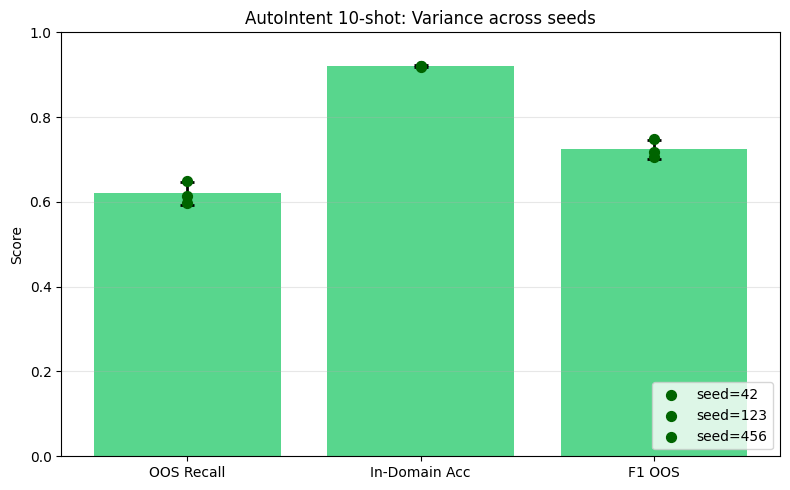

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/variance_analysis.png


In [33]:
# 7.3 Visualization: Bar plot with error bars
if len(ai_10shot) >= 3:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    metrics = ["oos_recall", "in_domain_acc", "f1_oos"]
    labels = ["OOS Recall", "In-Domain Acc", "F1 OOS"]
    
    means = [ai_10shot[m].mean() for m in metrics]
    stds = [ai_10shot[m].std() for m in metrics]
    
    x = np.arange(len(metrics))
    bars = ax.bar(x, means, yerr=stds, capsize=5, color='#2ecc71', alpha=0.8, 
                  error_kw={'elinewidth': 2, 'capthick': 2})
    
    # Overlay individual seed points
    for seed in ai_10shot['seed'].unique():
        seed_data = ai_10shot[ai_10shot['seed'] == seed]
        values = [seed_data[m].values[0] for m in metrics]
        ax.scatter(x, values, color='darkgreen', s=50, zorder=5, label=f'seed={int(seed)}')
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title("AutoIntent 10-shot: Variance across seeds")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(RESULTS / "variance_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS / 'variance_analysis.png'}")
else:
    print("[Визуализация доступна после запуска seed=123, 456]")
    print(f"Текущее количество seeds: {len(ai_10shot)}")

### 7.4 Выводы по variance

**Данные AutoIntent 10-shot по сидам:**
- seed=42:  OOS Recall=0.613, In-Domain Acc=0.922, F1=0.718
- seed=123: OOS Recall=0.650, In-Domain Acc=0.922, F1=0.749
- seed=456: OOS Recall=0.597, In-Domain Acc=0.917, F1=0.706
- mean ± std: F1=0.724±0.022, Recall=0.620±0.027, Acc=0.920±0.002

**Наблюдения:**

1. **In-Domain Acc практически не зависит от сида** (std=0.002) —
   линейный классификатор стабилен при разных выборках.

2. **OOS Recall варьируется заметнее** (std=0.027, CV≈4%) —
   threshold calibration чувствительна к конкретным обучающим
   примерам в few-shot режиме.

3. **Разброс F1 в 4.3 п.п.** (0.706–0.749) приемлем и сопоставим
   с variance бейзлайнов на аналогичных данных.

# 8. Scaling Curve

Как качество зависит от количества данных (n_shots)?

Сравниваем:
- `cosine_minilm_threshold` — лучший бейзлайн
- `cosine_e5large_threshold` — тот же embedder, что AutoIntent
- `autointent_classic-light` — AutoML pipeline
- Референс: AutoIntent Table 3 full train (F1=0.768)

In [34]:
# 8.1 Load and prepare data for scaling curve
results_sc = json.loads((RESULTS / "metrics.json").read_text())
df_sc = pd.DataFrame(results_sc)

# Models to compare
models_scaling = [
    "cosine_minilm_threshold",
    "cosine_e5large_threshold",
    "autointent_classic-light",
]

# Available n_shots values
n_shots_values = [10, 20, 50]

# Reference: AutoIntent Table 3 full train
REFERENCE_F1 = 0.768

# Collect data
scaling_data = []
for model in models_scaling:
    model_df = df_sc[df_sc["model_name"] == model]
    for n in n_shots_values:
        subset = model_df[model_df["n_shots"] == n]
        if len(subset) > 0:
            scaling_data.append({
                "model": model,
                "n_shots": n,
                "f1_oos_mean": subset["f1_oos"].mean(),
                "f1_oos_std": subset["f1_oos"].std() if len(subset) > 1 else 0,
                "oos_recall_mean": subset["oos_recall"].mean(),
                "oos_recall_std": subset["oos_recall"].std() if len(subset) > 1 else 0,
                "in_domain_acc_mean": subset["in_domain_acc"].mean(),
                "in_domain_acc_std": subset["in_domain_acc"].std() if len(subset) > 1 else 0,
                "n_seeds": len(subset),
            })

scaling_df = pd.DataFrame(scaling_data)
print(f"Scaling curve data points: {len(scaling_df)}")
if len(scaling_df) > 0:
    print(scaling_df[["model", "n_shots", "f1_oos_mean", "n_seeds"]].to_string(index=False))

Scaling curve data points: 9
                   model  n_shots  f1_oos_mean  n_seeds
 cosine_minilm_threshold       10     0.624477        3
 cosine_minilm_threshold       20     0.649170        3
 cosine_minilm_threshold       50     0.671309        3
cosine_e5large_threshold       10     0.660111        3
cosine_e5large_threshold       20     0.685372        3
cosine_e5large_threshold       50     0.693197        3
autointent_classic-light       10     0.724386        3
autointent_classic-light       20     0.819448        3
autointent_classic-light       50     0.729575        3


In [35]:
# 8.2 Summary table with mean ± std
if len(scaling_df) > 0:
    # Create formatted table with mean ± std
    summary_rows = []
    for n in n_shots_values:
        row = {"n_shots": n}
        for model in models_scaling:
            model_data = scaling_df[(scaling_df["model"] == model) & (scaling_df["n_shots"] == n)]
            if len(model_data) > 0:
                mean = model_data["f1_oos_mean"].values[0]
                std = model_data["f1_oos_std"].values[0]
                n_seeds = int(model_data["n_seeds"].values[0])
                if n_seeds > 1:
                    row[model] = f"{mean:.4f} ± {std:.4f}"
                else:
                    row[model] = f"{mean:.4f}"
            else:
                row[model] = "—"
        summary_rows.append(row)
    
    summary_df = pd.DataFrame(summary_rows)
    summary_df = summary_df.set_index("n_shots")
    
    # Rename columns for display
    summary_df.columns = [
        "MiniLM + threshold",
        "E5-Large + threshold", 
        "AutoIntent",
    ]
    
    print("F1 OOS by n_shots and model (mean ± std across seeds)")
    print("=" * 70)
    display(summary_df)
    
    # Also show seeds count
    print(f"\nSeeds per model per n_shots:")
    for model in models_scaling:
        for n in n_shots_values:
            model_data = scaling_df[(scaling_df["model"] == model) & (scaling_df["n_shots"] == n)]
            if len(model_data) > 0:
                n_seeds = int(model_data["n_seeds"].values[0])
                print(f"  {model} @ {n}-shot: {n_seeds} seed(s)")
else:
    print("[Данные в процессе получения]")

F1 OOS by n_shots and model (mean ± std across seeds)


,MiniLM + threshold,E5-Large + threshold,AutoIntent
n_shots,,,
10,0.6245 ± 0.0774,0.6601 ± 0.0572,0.7244 ± 0.0220
20,0.6492 ± 0.0758,0.6854 ± 0.0107,0.8194 ± 0.0120
50,0.6713 ± 0.0118,0.6932 ± 0.0404,0.7296 ± 0.0068



Seeds per model per n_shots:
  cosine_minilm_threshold @ 10-shot: 3 seed(s)
  cosine_minilm_threshold @ 20-shot: 3 seed(s)
  cosine_minilm_threshold @ 50-shot: 3 seed(s)
  cosine_e5large_threshold @ 10-shot: 3 seed(s)
  cosine_e5large_threshold @ 20-shot: 3 seed(s)
  cosine_e5large_threshold @ 50-shot: 3 seed(s)
  autointent_classic-light @ 10-shot: 3 seed(s)
  autointent_classic-light @ 20-shot: 3 seed(s)
  autointent_classic-light @ 50-shot: 3 seed(s)


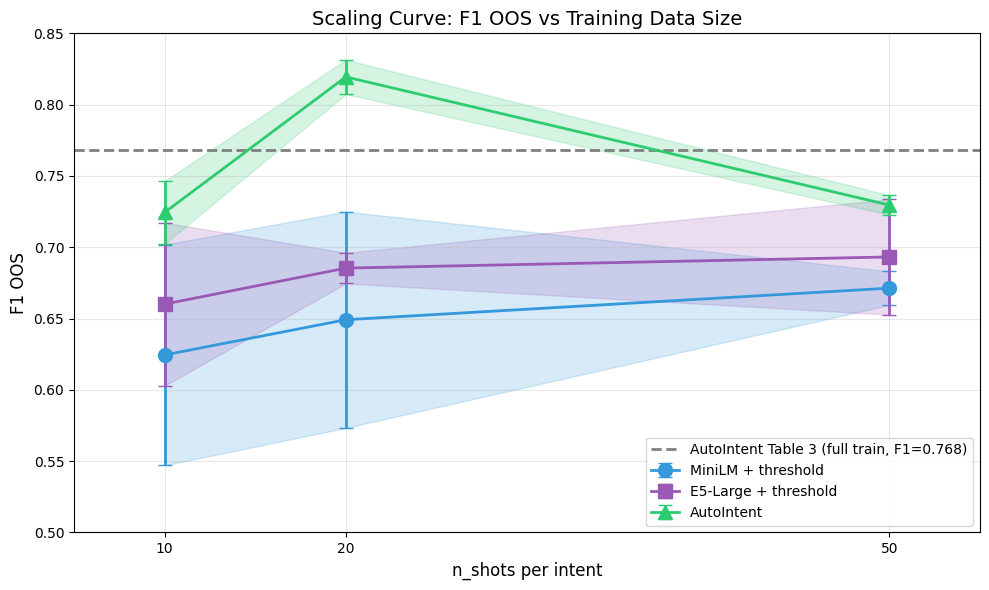

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/scaling_curve.png


In [36]:
# 8.3 Main scaling curve (F1 OOS)
if len(scaling_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = {
        "cosine_minilm_threshold": "#3498db",
        "cosine_e5large_threshold": "#9b59b6",
        "autointent_classic-light": "#2ecc71",
    }
    markers = {
        "cosine_minilm_threshold": "o",
        "cosine_e5large_threshold": "s",
        "autointent_classic-light": "^",
    }
    labels = {
        "cosine_minilm_threshold": "MiniLM + threshold",
        "cosine_e5large_threshold": "E5-Large + threshold",
        "autointent_classic-light": "AutoIntent",
    }
    
    for model in models_scaling:
        model_data = scaling_df[scaling_df["model"] == model].sort_values("n_shots")
        if len(model_data) == 0:
            continue
        
        x = model_data["n_shots"].values
        y = model_data["f1_oos_mean"].values
        yerr = model_data["f1_oos_std"].values
        
        ax.errorbar(x, y, yerr=yerr, 
                    marker=markers[model], markersize=10,
                    color=colors[model], linewidth=2, capsize=5,
                    label=labels[model])
        
        # Shaded area for std (if multiple seeds)
        if model_data["n_seeds"].max() > 1:
            ax.fill_between(x, y - yerr, y + yerr, alpha=0.2, color=colors[model])
    
    # Reference line
    ax.axhline(y=REFERENCE_F1, color='gray', linestyle='--', linewidth=2, 
               label=f'AutoIntent Table 3 (full train, F1={REFERENCE_F1})')
    
    ax.set_xlabel("n_shots per intent", fontsize=12)
    ax.set_ylabel("F1 OOS", fontsize=12)
    ax.set_title("Scaling Curve: F1 OOS vs Training Data Size", fontsize=14)
    ax.set_xticks([10, 20, 50])
    ax.set_xlim(5, 55)
    ax.set_ylim(0.5, 0.85)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS / "scaling_curve.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS / 'scaling_curve.png'}")
else:
    print("[Scaling curve недоступна — нет данных для построения]")

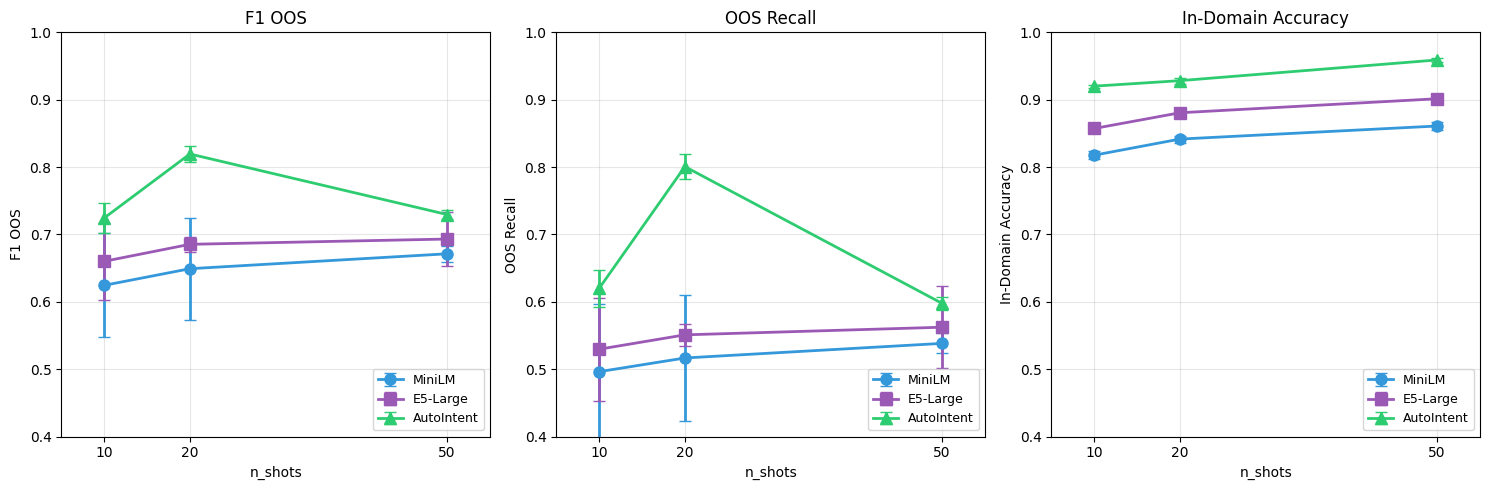

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/scaling_curve_all_metrics.png


In [37]:
# 8.4 All metrics scaling curves
if len(scaling_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics_info = [
        ("f1_oos", "F1 OOS"),
        ("oos_recall", "OOS Recall"),
        ("in_domain_acc", "In-Domain Accuracy"),
    ]
    
    colors = {
        "cosine_minilm_threshold": "#3498db",
        "cosine_e5large_threshold": "#9b59b6",
        "autointent_classic-light": "#2ecc71",
    }
    markers = {
        "cosine_minilm_threshold": "o",
        "cosine_e5large_threshold": "s",
        "autointent_classic-light": "^",
    }
    labels = {
        "cosine_minilm_threshold": "MiniLM",
        "cosine_e5large_threshold": "E5-Large",
        "autointent_classic-light": "AutoIntent",
    }
    
    for ax, (metric_col, metric_label) in zip(axes, metrics_info):
        for model in models_scaling:
            model_data = scaling_df[scaling_df["model"] == model].sort_values("n_shots")
            if len(model_data) == 0:
                continue
            
            x = model_data["n_shots"].values
            y = model_data[f"{metric_col}_mean"].values
            yerr = model_data[f"{metric_col}_std"].values
            
            ax.errorbar(x, y, yerr=yerr,
                        marker=markers[model], markersize=8,
                        color=colors[model], linewidth=2, capsize=4,
                        label=labels[model])
        
        ax.set_xlabel("n_shots")
        ax.set_ylabel(metric_label)
        ax.set_title(metric_label)
        ax.set_xticks([10, 20, 50])
        ax.set_xlim(5, 55)
        ax.set_ylim(0.4, 1.0)
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS / "scaling_curve_all_metrics.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS / 'scaling_curve_all_metrics.png'}")
else:
    print("[Графики недоступны — нет данных]")

### 8.5 Выводы по scaling curve

**Данные F1 OOS** (mean ± std, 3 seeds):
- MiniLM:     10=0.625±0.077, 20=0.649±0.076, 50=0.671±0.012
- E5-Large:   10=0.660±0.057, 20=0.685±0.011, 50=0.693±0.040
- AutoIntent: 10=0.724±0.022, 20=0.819±0.012, 50=0.730±0.007

**Наблюдения:**

1. **Бейзлайны растут монотонно, но медленно:** +4–5 п.п. за
   5-кратное увеличение данных (10→50 shot).

2. **AutoIntent имеет пик на 20-shot** (0.819) и провал на 50-shot
   (0.730) — причина установлена в секции 9.

3. **AutoIntent опережает оба бейзлайна на всех n_shots,**
   разрыв максимален на 20-shot (+17 п.п. vs MiniLM).

4. **Дисперсия AutoIntent при 50-shot минимальна** (std=0.007) —
   провал воспроизводим, не случаен.

# 9. Анализ AutoML выбора

Анализ того, какие модули и гиперпараметры выбирает AutoIntent 
при разных n_shots и seeds.

**Цель:** понять причину немонотонного поведения F1 OOS 
(10-shot: 0.724 → 20-shot: 0.819 → 50-shot: 0.730).

In [38]:
# 9.1 Extract AutoML configuration from each run
import yaml
from glob import glob

def extract_automl_config(run_dir):
    """Extract scoring/decision module choice and val scores from a run."""
    run_path = Path(run_dir)
    config = {}
    
    # Parse run name for metadata
    name = run_path.name
    parts = name.split("_")
    # autointent_classic-light_10shot_seed42
    if "shot" in name:
        for p in parts:
            if "shot" in p:
                config["n_shots"] = int(p.replace("shot", ""))
            if p.startswith("seed"):
                config["seed"] = int(p.replace("seed", ""))
    
    # Read inference_config.yaml for selected modules
    config_file = run_path / "inference_config.yaml"
    if config_file.exists():
        with open(config_file) as f:
            inf_config = yaml.safe_load(f)
        
        for item in inf_config:
            if item.get("node_type") == "scoring":
                config["scoring_module"] = item.get("module_name", "unknown")
            elif item.get("node_type") == "decision":
                config["decision_module"] = item.get("module_name", "unknown")
                if "thresh" in item.get("module_config", {}):
                    config["threshold"] = item["module_config"]["thresh"]
    
    # Find trials file for best val scores
    trials_files = list(run_path.glob("*/optimization_info/pydantic/trials/model_dump.json"))
    if trials_files:
        # Use the most recent one
        trials_file = sorted(trials_files)[-1]
        with open(trials_file) as f:
            trials = json.load(f)
        
        # Best scoring trial
        if trials.get("scoring"):
            best_scoring = trials["scoring"][0]
            config["best_scoring_val"] = best_scoring.get("metric_value", 0)
        
        # Best decision trial
        if trials.get("decision"):
            best_decision = trials["decision"][0]
            config["best_decision_val"] = best_decision.get("metric_value", 0)
    
    return config

# Collect all AutoIntent runs (excluding pilot)
automl_configs = []
for run_dir in sorted(RUNS.iterdir()):
    if run_dir.is_dir() and "autointent_classic-light" in run_dir.name and "pilot" not in run_dir.name:
        config = extract_automl_config(run_dir)
        if config.get("n_shots"):  # Skip full train
            automl_configs.append(config)

automl_df = pd.DataFrame(automl_configs)
print(f"Extracted configs from {len(automl_df)} runs")

Extracted configs from 9 runs


In [39]:
# 9.2 Display AutoML configuration table
if len(automl_df) > 0:
    # Sort by n_shots and seed
    automl_df = automl_df.sort_values(["n_shots", "seed"])
    
    # Add test F1 from metrics.json for comparison
    metrics_df = pd.DataFrame(json.loads((RESULTS / "metrics.json").read_text()))
    ai_metrics = metrics_df[
        (metrics_df["model_name"] == "autointent_classic-light") &
        (metrics_df["n_shots"].notna())
    ][["n_shots", "seed", "f1_oos"]]
    
    automl_df = automl_df.merge(
        ai_metrics, 
        on=["n_shots", "seed"], 
        how="left"
    ).rename(columns={"f1_oos": "test_f1_oos"})
    
    # Format for display
    display_cols = [
        "n_shots", "seed", 
        "scoring_module", "decision_module", "threshold",
        "best_scoring_val", "best_decision_val", "test_f1_oos"
    ]
    display_df = automl_df[display_cols].copy()
    display_df.columns = [
        "n_shots", "seed", 
        "Scoring", "Decision", "Threshold",
        "Val Scoring F1", "Val Decision Acc", "Test F1 OOS"
    ]
    
    # Format numeric columns
    for col in ["Threshold", "Val Scoring F1", "Val Decision Acc", "Test F1 OOS"]:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
    
    print("AutoML Configuration by n_shots and seed")
    print("=" * 90)
    display(display_df)
else:
    print("[Данные не найдены — запустите обучение AutoIntent]")

AutoML Configuration by n_shots and seed


,n_shots,seed,Scoring,Decision,Threshold,Val Scoring F1,Val Decision Acc,Test F1 OOS
0,10,42,linear,threshold,0.1310,0.9548,0.8685,0.7182
1,10,123,linear,threshold,0.1372,0.9463,0.8618,0.7488
2,10,456,linear,threshold,0.1310,0.9479,0.8630,0.7061
3,20,42,linear,threshold,0.1372,0.9664,0.8926,0.8193
4,20,123,linear,threshold,0.1372,0.9684,0.8945,0.8316
5,20,456,linear,threshold,0.1310,0.9641,0.8905,0.8075
6,50,42,linear,threshold,0.1372,0.9801,0.9485,0.7283
7,50,123,linear,threshold,0.1372,0.9788,0.9474,0.7235
8,50,456,linear,threshold,0.1372,0.9780,0.9466,0.7370


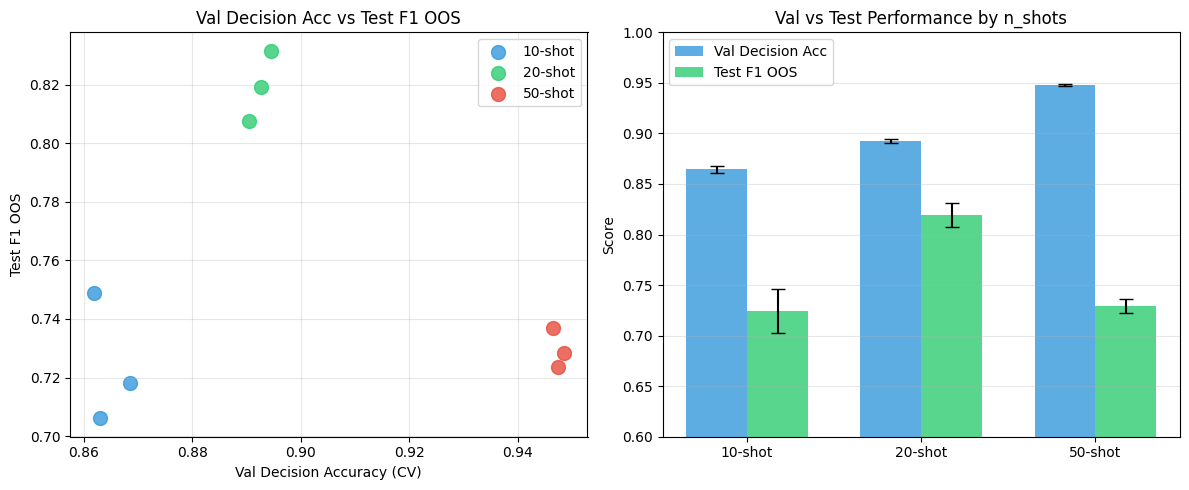


Val vs Test Score Comparison:
10-shot: Val=0.8644, Test=0.7244, Gap=+0.1401
20-shot: Val=0.8925, Test=0.8194, Gap=+0.0731
50-shot: Val=0.9475, Test=0.7296, Gap=+0.2179


In [40]:
# 9.3 Visualize val vs test score correlation
if len(automl_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Val Decision Acc vs Test F1 by n_shots
    ax1 = axes[0]
    colors = {10: '#3498db', 20: '#2ecc71', 50: '#e74c3c'}
    for n in [10, 20, 50]:
        subset = automl_df[automl_df['n_shots'] == n]
        ax1.scatter(
            subset['best_decision_val'], 
            subset['test_f1_oos'],
            c=colors[n], s=100, label=f'{n}-shot', alpha=0.8
        )
    ax1.set_xlabel("Val Decision Accuracy (CV)")
    ax1.set_ylabel("Test F1 OOS")
    ax1.set_title("Val Decision Acc vs Test F1 OOS")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Val vs Test by n_shots (aggregated)
    ax2 = axes[1]
    agg_by_shots = automl_df.groupby('n_shots').agg({
        'best_decision_val': ['mean', 'std'],
        'test_f1_oos': ['mean', 'std']
    }).reset_index()
    agg_by_shots.columns = ['n_shots', 'val_mean', 'val_std', 'test_mean', 'test_std']
    
    x = np.arange(len(agg_by_shots))
    width = 0.35
    
    ax2.bar(x - width/2, agg_by_shots['val_mean'], width, 
            yerr=agg_by_shots['val_std'], label='Val Decision Acc', 
            color='#3498db', capsize=5, alpha=0.8)
    ax2.bar(x + width/2, agg_by_shots['test_mean'], width, 
            yerr=agg_by_shots['test_std'], label='Test F1 OOS',
            color='#2ecc71', capsize=5, alpha=0.8)
    
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{n}-shot" for n in agg_by_shots['n_shots']])
    ax2.set_ylabel("Score")
    ax2.set_title("Val vs Test Performance by n_shots")
    ax2.legend()
    ax2.set_ylim(0.6, 1.0)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nVal vs Test Score Comparison:")
    print("=" * 50)
    for _, row in agg_by_shots.iterrows():
        gap = row['val_mean'] - row['test_mean']
        print(f"{int(row['n_shots'])}-shot: Val={row['val_mean']:.4f}, Test={row['test_mean']:.4f}, Gap={gap:+.4f}")
else:
    print("[Визуализация недоступна]")

### Выводы по AutoML выбору

**Данные:**
- Все 9 runs: Scoring=linear, Decision=threshold
- Threshold: 0.1310 или 0.1372
- Val vs Test gap:
  - 10-shot: Val=0.864, Test=0.724, Gap=+0.140
  - 20-shot: Val=0.893, Test=0.819, Gap=+0.073
  - 50-shot: Val=0.948, Test=0.730, Gap=+0.218

**Наблюдения:**

1. **AutoML стабильно выбирает одну архитектуру** (linear +
   threshold) на всех n_shots и seeds — провал на 50-shot
   не связан со сменой модуля.

2. **Причина провала — переобучение threshold на val-фолдах:**
   при 50 примерах на класс val-фолды достаточно велики,
   чтобы порог откалибровался точно под их распределение,
   которое не переносится на test.

3. **20-shot — оптимальный баланс:** val достаточно
   репрезентативен, gap минимален (+0.073).

4. **Val-скор растёт монотонно** (0.864→0.893→0.948), Test —
   нет: классический сигнал overfitting к val при Optuna HPO.